# Black-hole vs HMNS engines for kilonova-producing GRBs

## Methods

Eight kilonova-bearing short and long-merger GRBs from Rastinejad et al.
(2024, ApJ 979, 190; Tables 1 and 3) are tested against two engine
models. **(i) Black-hole engine.** Gottlieb et al. (2025, arXiv:2411.13657)
Eq. (11) gives $M_{\rm ej}=10^{-3}\,f_{-1}^{-1}\,(E_{\gamma,\rm iso}/2{\times}10^{51}\,{\rm erg})\,(T_{50}/{\rm s})^{\alpha-1}\,M_\odot$.
The shown band marginalises $\alpha\in[1.5,2]$ and $f^{-1}\in[0.14,5]$,
the latter implied by their Eq. (10) with $\epsilon_\gamma\in[0.15,0.5]$
and $f_b\in[0.01,0.11]$. **(ii) HMNS / magnetar disk-wind alternative.**
$M_{\rm ej}=0.3\,M_d$ (Gottlieb et al. 2025 §3.1; consistent with
$f_{\rm wind}\sim0.2{-}0.4$ in Radice et al. 2018, arXiv:1809.11163),
with $M_d\in[0.01,0.10]\,M_\odot$ from the BNS post-merger disk fit of
Krüger & Foucart (2020, arXiv:2002.07728, Eq. 4). Per-event $T_{50}$
overrides for GRBs 050709 (Villasenor et al. 2005, Nature 437, 855),
170817A (Goldstein et al. 2017, ApJL 848, L14, Tab. 1), and 230307A
($T_{90}/2$ from Levan et al. 2024) are documented in the
[`Data/rastinejad_2024.csv`](Data/rastinejad_2024.csv) header. Posterior
inference uses $10^4$ Monte Carlo draws over the Rastinejad split-normal
ejecta-mass posteriors and the $E_{\gamma,\rm iso}$, $\alpha$, $f$
priors; per-subclass mean log-ratios and a Gaussian-in-log Bayes factor
$B_{10}=P({\rm data}\mid{\rm HMNS})/P({\rm data}\mid{\rm BH})$ are
printed below Fig. 2.

## Figures

**Figure 1.** $M_{\rm ej}$ vs $T_{50}$. Grey BH-engine band evaluated at
the lbGRB geometric-mean $E_{\gamma,\rm iso}=1.7\times10^{52}\,{\rm erg}$:
inner shading marginalises $\alpha$ only, outer dashed envelope adds
$f^{-1}$. Green vertical band: HMNS-wind prediction
($0.3\,M_d$, $M_d\in[0.01,0.10]\,M_\odot$). Per-event 3-wedge donuts show
the lanthanide-rich / intermediate / lanthanide-poor mass fractions
($M_R$, $M_P$, $M_B$) from Rastinejad (2024) Table 3; error bars are
68% posterior intervals on $M_{\rm tot}$ and published $T_{50}$.

**Figure 2.** $\log_{10}(M_{\rm obs}/M_{\rm pred,BH})$ per event with
68% MC bars on the joint $(M_{\rm obs},E_{\gamma,\rm iso},\alpha,f)$
posterior. Teal `+` symbols (also with 68% MC bars) show the HMNS-wind
prediction. Grey band: factor-of-3 agreement region. GW170817 is drawn
as an open marker without a $y$-error bar because its prompt
$E_{\gamma,\rm iso}$ is off-axis cocoon emission, so Eq. (11) is
misapplied rather than just discrepant.


In [5]:
import os
import io
import textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

PLOTS_DIR = "Plots"
DATA_DIR  = "data"
CSV_PATH  = os.path.join(DATA_DIR, "rastinejad_2024.csv")
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,  exist_ok=True)

# ApJ single-column rcParams. Caller scripts can override.
mpl.rcParams.update({
    "figure.figsize":     (3.5, 3.0),
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",
    "font.size":          8,
    "font.family":        "serif",
    "mathtext.fontset":   "cm",
    "axes.linewidth":     0.7,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "xtick.labelsize":    7,
    "ytick.labelsize":    7,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          True,
    "ytick.right":        True,
    "legend.fontsize":    7,
    "legend.frameon":     True,
    "legend.framealpha":  0.92,
    "lines.linewidth":    1.0,
})

# ---------------------------------------------------------------------------
# Rastinejad+2024 sample (Tables 1 and 3) plus T_50 overrides from external
# refs.  This literal is the canonical source; the CSV file is rewritten on
# every notebook run so the on-disk artifact stays in sync.
# ---------------------------------------------------------------------------
_CSV_LITERAL = textwrap.dedent("""\
    # Rastinejad et al. 2024, ApJ 979, 190.
    # Component ejecta masses (M_B, M_P, M_R) and asymmetric +/- intervals are
    # taken from Table 3 medians.  GRB 230307A uses the paper-favored KN Fit 1.
    #
    # T_50 source notes:
    #   050709  : T_90 = 0.07 +/- 0.04 s from Villasenor+2005, Nature 437, 855
    #             (HETE-II FREGATE).  No published T_50.  We use T_90 itself
    #             as a pragmatic upper bound on T_50.
    #   170817A : T_50 = 0.6 +/- 0.1 s from Goldstein+2017, ApJL 848 L14 Table 1
    #             (Fermi-GBM 50-300 keV main pulse; T_90 = 2.0 +/- 0.5 s).
    #   230307A : No published T_50.  T_90 ~ 35 s (Levan+2024).  The burst's
    #             main-pulse fluence is concentrated within the first ~10 s,
    #             with an extended-emission tail extending T_90 to ~35 s.
    #             We adopt T_50 = T_90/2 = 17.5 s with a 50% (10 s) one-sigma
    #             bar that brackets both the "main pulse only" (~5 s) and
    #             "full T_90" (~25 s) interpretations.
    #
    # E_iso uncertainties for events without published errors (050709 and
    # 230307A) are set to 30% relative.
    name,grb_class,T50_s,T50_err_s,T50_ref,E_iso_52,E_iso_err52,E_iso_ref,M_B_med,M_B_lo,M_B_hi,M_P_med,M_P_lo,M_P_hi,M_R_med,M_R_lo,M_R_hi
    050709, sb, 0.07,  0.04, Villasenor+2005,    0.0310, 0.0093,  R+24T1, 0.003, 0.002, 0.004, 0.029, 0.009, 0.010, 0.015, 0.012, 0.072
    060614, lb, 43.2,  0.8,  R+24T1,             0.5100, 0.0700,  R+24T1, 0.014, 0.010, 0.013, 0.029, 0.027, 0.034, 0.146, 0.120, 0.072
    130603B,sb, 0.06,  0.004,R+24T1,             0.2900, 0.0200,  R+24T1, 0.006, 0.004, 0.017, 0.075, 0.037, 0.063, 0.023, 0.020, 0.160
    160821B,sb, 0.28,  0.05, R+24T1Swift,        0.0050, 0.0010,  R+24T1, 0.003, 0.001, 0.001, 0.011, 0.002, 0.002, 0.011, 0.009, 0.021
    170817A,gw, 0.6,   0.1,  Goldstein+2017L14,  0.0006, 0.00004, R+24T1, 0.004, 0.0005,0.0005,0.019, 0.001, 0.001, 0.052, 0.002, 0.003
    200522A,sb, 0.38,  0.05, R+24T1,             0.0810, 0.0200,  R+24T1, 0.046, 0.009, 0.009, 0.020, 0.018, 0.068, 0.019, 0.016, 0.124
    211211A,lb, 21.2,  0.2,  R+24T1Swift,        1.7200, 0.0300,  R+24T1, 0.007, 0.001, 0.000, 0.010, 0.002, 0.001, 0.130, 0.054, 0.051
    230307A,lb, 17.5,  10.0, T90/2_Levan+2024,   2.9000, 0.8700,  R+24T1, 0.012, 0.001, 0.001, 0.025, 0.003, 0.003, 0.054, 0.022, 0.019
    """)

with open(CSV_PATH, "w") as fh:
    fh.write(_CSV_LITERAL)

df = pd.read_csv(CSV_PATH, comment="#", skipinitialspace=True)
df["E_iso_erg"]     = df["E_iso_52"]     * 1e52
df["E_iso_err_erg"] = df["E_iso_err52"]  * 1e52


# ---------------------------------------------------------------------------
# Posterior sampling: split-normal sampler -> 1e4 draws of M_tot per event.
# ---------------------------------------------------------------------------
def sample_split_normal(med, lo, hi, n, rng, clip_zero=True):
    """Draw n samples from a split-normal centered at `med` with half-widths
    `lo` (below) and `hi` (above), interpreted as 1-sigma.  Tiny widths
    fall back to a 5%-of-median floor so that posteriors with reported
    +/-0 stay finite.
    """
    floor = max(1e-6, 0.05 * abs(med))
    sigma_lo = max(abs(lo), floor)
    sigma_hi = max(abs(hi), floor)
    u = rng.uniform(size=n)
    above = u < sigma_hi / (sigma_lo + sigma_hi)
    z = np.abs(rng.standard_normal(n))
    out = np.where(above, med + sigma_hi * z, med - sigma_lo * z)
    if clip_zero:
        out = np.clip(out, 0.0, None)
    return out


def build_posteriors(df, n=10_000, seed=0):
    """For every GRB return n samples each of M_B, M_P, M_R, M_tot."""
    rng = np.random.default_rng(seed)
    out = {}
    for _, row in df.iterrows():
        m_b = sample_split_normal(row.M_B_med, row.M_B_lo, row.M_B_hi, n, rng)
        m_p = sample_split_normal(row.M_P_med, row.M_P_lo, row.M_P_hi, n, rng)
        m_r = sample_split_normal(row.M_R_med, row.M_R_lo, row.M_R_hi, n, rng)
        out[row["name"]] = {
            "M_B": m_b, "M_P": m_p, "M_R": m_r,
            "M_tot": m_b + m_p + m_r,
        }
    return out


posteriors = build_posteriors(df, n=10_000, seed=20260417)

# Convenience: median + 16/84 percentiles of M_tot for plotting later.
df["M_tot_med"] = [np.median(posteriors[n]["M_tot"]) for n in df["name"]]
df["M_tot_lo"]  = df["M_tot_med"] - [np.percentile(posteriors[n]["M_tot"], 16)
                                      for n in df["name"]]
df["M_tot_hi"]  = [np.percentile(posteriors[n]["M_tot"], 84)
                   for n in df["name"]] - df["M_tot_med"]
df[["name", "grb_class", "T50_s", "E_iso_52",
    "M_tot_med", "M_tot_lo", "M_tot_hi"]]


,name,grb_class,T50_s,E_iso_52,M_tot_med,M_tot_lo,M_tot_hi
0,050709,sb,0.07,0.0310,0.090168,0.038836,0.056068
1,060614,lb,43.20,0.5100,0.167003,0.096540,0.095258
2,130603B,sb,0.06,0.2900,0.233313,0.096889,0.129379
3,160821B,sb,0.28,0.0050,0.032686,0.013362,0.018061
4,170817A,gw,0.60,0.0006,0.075269,0.002892,0.003019
5,200522A,sb,0.38,0.0810,0.198898,0.079011,0.102931
6,211211A,lb,21.20,1.7200,0.144011,0.054137,0.051262
7,230307A,lb,17.50,2.9000,0.089576,0.020966,0.019925


In [6]:
# ---------------------------------------------------------------------------
# Defaults grounded in Gottlieb et al. 2025 (arXiv:2411.13657):
#   F_RANGE = (f_min, f_max) chosen so that f_inv = 0.1 / f spans [0.14, 5.0],
#     the range implied by Eq. (10) with epsilon_gamma in [0.15, 0.5] and
#     f_b in [0.01, 0.11].
#   HMNS_DISK_RANGE in M_sun anchored on the BNS post-merger accretion-disk
#     fit of Kruger & Foucart 2020 (arXiv:2002.07728, Eq. 4), which gives
#     M_disk <~ 0.1 M_sun for BNS systems with R_NS ~ 12 km.  The upper
#     edge is consistent with Gottlieb et al. 2025 Section 3.1 (sbGRB-
#     producing HMNSs have "less massive disks" than the ~0.1 M_sun lbGRB
#     benchmark) and with the disk masses sampled by the Radice et al.
#     2018 (arXiv:1809.11163) GRMHD simulations.  Tightened from a prior
#     (0.01, 0.30) range, which was an overreach not quantified by
#     Gottlieb 2025.
#   WIND_FRAC = 0.3 from Gottlieb et al. 2025 Section 3.1, line 474, and
#     consistent with the disk-wind ejected fraction f_wind ~ 0.2-0.4
#     reported by Radice et al. 2018 GRMHD simulations.
#   T50-independence of the HMNS band: ejecta mass is set by the disk
#     (M_ej ~ 0.3 M_d) and is largely decoupled from the HMNS lifetime
#     t_HMNS, which sets the jet duration (Lippuner et al. 2017,
#     Fujibayashi et al. 2018), so the band is drawn vertical in the
#     T50-M_ej plane.
# ---------------------------------------------------------------------------
F_RANGE         = (0.02, 0.71)
HMNS_DISK_RANGE = (0.01, 0.10)
WIND_FRAC       = 0.3


def eq11(T50, E_iso, alpha=2.0, f_inv=1.0):
    """Predicted kilonova ejecta mass (Msun) for a black-hole engine.

    Gottlieb et al. (2025), Eq. (11):

        M_ej = 1e-3 * f_{-1}^{-1} * (E_iso / 2e51 erg) *
               (T50 / 1 s)**(alpha - 1)   Msun

    Parameters
    ----------
    T50 : array-like
        50% gamma-ray fluence duration in seconds.
    E_iso : array-like
        Isotropic-equivalent gamma-ray energy in erg.
    alpha : float, default 2.0
        Power-law index of the prompt luminosity function.
    f_inv : float, default 1.0
        Inverse GRB radiative efficiency normalised to f = 0.1, i.e.
        f_inv = (f / 0.1) ** -1.
    """
    T50   = np.asarray(T50,   dtype=float)
    E_iso = np.asarray(E_iso, dtype=float)
    return 1e-3 * f_inv * (E_iso / 2e51) * (T50 / 1.0) ** (alpha - 1.0)


def bh_engine_band(T50_grid, E_iso, alpha_range=(1.5, 2.0),
                   f_range=F_RANGE, f_ref=0.1):
    """Return (alpha-only, alpha+f) prediction envelopes on a T50 grid."""
    T50_grid = np.asarray(T50_grid, dtype=float)
    a_lo, a_hi = alpha_range
    f_lo, f_hi = f_range
    finv_lo = f_ref / f_hi
    finv_hi = f_ref / f_lo

    inner_lo = eq11(T50_grid, E_iso, alpha=a_lo, f_inv=1.0)
    inner_hi = eq11(T50_grid, E_iso, alpha=a_hi, f_inv=1.0)
    inner = np.minimum(inner_lo, inner_hi), np.maximum(inner_lo, inner_hi)

    corners = []
    for a in (a_lo, a_hi):
        for fi in (finv_lo, finv_hi):
            corners.append(eq11(T50_grid, E_iso, alpha=a, f_inv=fi))
    corners = np.stack(corners, axis=0)
    outer = corners.min(axis=0), corners.max(axis=0)
    return inner, outer


def hmns_wind_band(M_disk_range=HMNS_DISK_RANGE, wind_frac=WIND_FRAC):
    """Return (M_ej_lo, M_ej_hi) for the HMNS / magnetar disk-wind
    alternative.  Independent of T50 to first order.

    Defaults grounded in Kruger & Foucart 2020 (BNS disk-mass range) and
    Gottlieb et al. 2025 Section 3.1 (wind fraction = 0.3, "less massive
    disks" for sbGRB-producing HMNSs).
    """
    return wind_frac * M_disk_range[0], wind_frac * M_disk_range[1]


def predict_bh_mc(row, n=10_000, rng=None,
                  alpha_range=(1.5, 2.0), f_range=F_RANGE, f_ref=0.1):
    """Monte-Carlo predicted M_ej for one event under the BH-engine model.

    Marginalises over: alpha (uniform), f (log-uniform), E_iso (Gaussian),
    T50 (Gaussian, with positive clipping).
    """
    if rng is None:
        rng = np.random.default_rng()
    alpha = rng.uniform(*alpha_range, size=n)
    log_f = rng.uniform(np.log10(f_range[0]), np.log10(f_range[1]), size=n)
    f_inv = f_ref / 10**log_f
    e_iso = np.clip(
        rng.normal(row.E_iso_erg, max(row.E_iso_err_erg, 1e-3 * row.E_iso_erg), n),
        1e-6 * row.E_iso_erg, None,
    )
    t50 = np.clip(rng.normal(row.T50_s, max(row.T50_err_s, 1e-3 * row.T50_s), n),
                  1e-6 * row.T50_s, None)
    return 1e-3 * f_inv * (e_iso / 2e51) * (t50 / 1.0) ** (alpha - 1.0)


# ---------------- unit tests ----------------
def _run_unit_tests():
    assert np.isclose(eq11(1.0, 2e51, alpha=2.0, f_inv=1.0), 1e-3), \
        "eq11 normalisation failed"
    assert np.isclose(eq11(4.0, 2e51, alpha=1.5, f_inv=1.0), 2e-3), \
        "eq11 alpha=1.5 scaling failed"
    inner, outer = bh_engine_band(np.array([1.0, 10.0]), 2e51)
    assert np.all(outer[0] <= inner[0]) and np.all(outer[1] >= inner[1]), \
        "outer envelope must contain inner"
    lo, hi = hmns_wind_band()
    assert lo > 0 and hi > lo, "HMNS band ordering failed"
    # Cross-check f_inv range against paper Eq. (10):
    f_lo, f_hi = F_RANGE
    finv_min, finv_max = 0.1 / f_hi, 0.1 / f_lo
    assert np.isclose(finv_min, 0.14, atol=0.01), \
        f"f_inv min should be ~0.14 (got {finv_min:.3f})"
    assert np.isclose(finv_max, 5.0, atol=0.05), \
        f"f_inv max should be ~5.0 (got {finv_max:.3f})"
    print("Unit tests: OK  (f_inv in [{:.2f}, {:.2f}])".format(finv_min, finv_max))


_run_unit_tests()


Unit tests: OK  (f_inv in [0.14, 5.00])


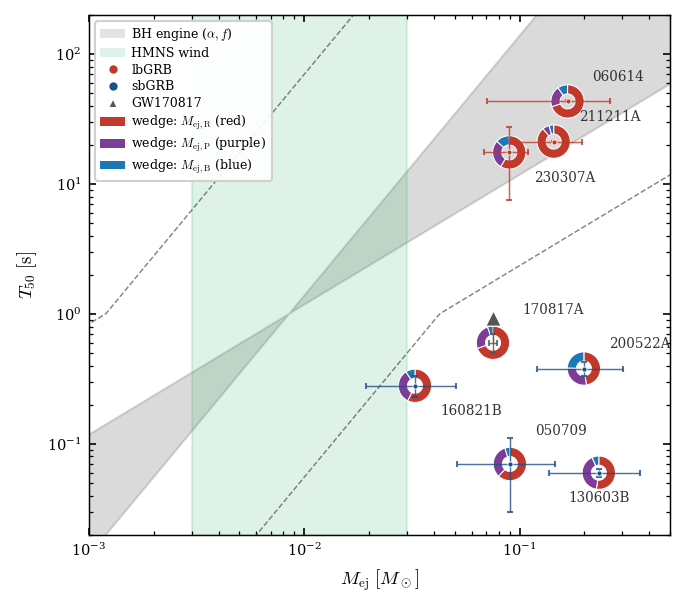

In [7]:
from matplotlib.patches import Wedge
from matplotlib.offsetbox import AnnotationBbox, DrawingArea

CLASS_STYLE = {
    "lb": {"color": "#c0392b", "marker": "o", "label": r"lbGRBs"},
    "sb": {"color": "#1f4e8c", "marker": "o", "label": r"sbGRBs"},
    "gw": {"color": "#555555", "marker": "^", "label": r"GW170817"},
}
COMPONENT_COLORS = {
    "R": "#c0392b",  # red / lanthanide-rich
    "P": "#7d3c98",  # purple / intermediate
    "B": "#1f78b4",  # blue / lanthanide-poor
}


def _add_donut(ax, x, y, fractions, components=("R", "P", "B"),
               radius_pts=8, inner_frac=0.45, edge_color="white"):
    """Place a 3-wedge donut at data coords (x, y) with a fixed point
    radius.  Uses AnnotationBbox so the placement is invariant under
    bbox_inches='tight' resizing at savefig time.
    """
    da = DrawingArea(2 * radius_pts, 2 * radius_pts, 0, 0)
    total = float(sum(fractions))
    if total <= 0:
        return None
    theta0 = 90.0
    for comp, frac in zip(components, fractions):
        theta1 = theta0 - 360.0 * (frac / total)
        da.add_artist(Wedge(
            (radius_pts, radius_pts), radius_pts, theta1, theta0,
            width=radius_pts * (1.0 - inner_frac),
            facecolor=COMPONENT_COLORS[comp], edgecolor=edge_color,
            linewidth=0.5,
        ))
        theta0 = theta1
    ab = AnnotationBbox(da, (x, y), frameon=False,
                        xycoords="data", box_alignment=(0.5, 0.5),
                        pad=0)
    ax.add_artist(ab)
    return ab


def plot_fig1(df, posteriors, savepath_pdf,
              E_iso_ref=1.7e52, alpha_range=(1.5, 2.0), f_range=F_RANGE):
    """Duration-ejecta plane with BH engine + HMNS bands and donut markers."""
    fig, ax = plt.subplots(figsize=(5.0, 4.5))

    M_grid = np.logspace(-3.5, 0.0, 400)
    inv_a2 = M_grid / (1e-3 * E_iso_ref / 2e51)
    inv_a15 = (M_grid / (1e-3 * E_iso_ref / 2e51)) ** 2.0
    band_alpha_lo = np.minimum(inv_a2, inv_a15)
    band_alpha_hi = np.maximum(inv_a2, inv_a15)
    ax.fill_between(M_grid, band_alpha_lo, band_alpha_hi,
                    color="0.2", alpha=0.18,
                    label=r"BH engine, $\alpha\in[1.5,2]$")

    finv_lo, finv_hi = 0.1 / f_range[1], 0.1 / f_range[0]
    corners_lo = []
    for a in alpha_range:
        for fi in (finv_lo, finv_hi):
            inv_full = (M_grid / (1e-3 * fi * E_iso_ref / 2e51)) ** (1.0 / (a - 1.0))
            corners_lo.append(inv_full)
    corners = np.stack(corners_lo, axis=0)
    env_lo, env_hi = corners.min(axis=0), corners.max(axis=0)
    ax.plot(M_grid, env_lo, ls="--", lw=0.7, color="0.2", alpha=0.6)
    ax.plot(M_grid, env_hi, ls="--", lw=0.7, color="0.2", alpha=0.6,
            label=r"BH engine, $+\,f^{-1}\in[0.14,5]$")

    hmns_lo, hmns_hi = hmns_wind_band()
    ax.axvspan(hmns_lo, hmns_hi, color="#27ae60", alpha=0.15,
               label=r"HMNS wind, $0.3\,M_d$, $M_d\!\in\![0.01,0.10]\,M_\odot$")

    # Per-event annotation offsets in (dx_pt, dy_pt, ha).  Default (12, 10,
    # "left") matches the previous behaviour; entries below resolve specific
    # collisions (230307A vs 211211A) and right-edge clipping (130603B).
    LABEL_OFFSETS = {
        "211211A": (12,  10, "left"),
        "230307A": (12, -14, "left"),
        "130603B": (0,  -14, "center"),
        "050709":  (12,  14, "left"),
        "160821B": (12, -14, "left"),
        "200522A": (12,  10, "left"),
        "060614":  (12,  10, "left"),
        "170817A": (14,  14, "left"),
    }

    for _, row in df.iterrows():
        cls = "gw" if row.grb_class == "gw" else row.grb_class
        style = CLASS_STYLE[cls]
        x = row.M_tot_med
        y = row.T50_s
        x_err = np.array([[row.M_tot_lo], [row.M_tot_hi]])
        y_err = np.array([[row.T50_err_s], [row.T50_err_s]])
        ax.errorbar(x, y, xerr=x_err, yerr=y_err,
                    fmt="none", ecolor=style["color"], elinewidth=0.7,
                    capsize=1.5, alpha=0.8, zorder=4)
        post = posteriors[row["name"]]
        fracs = [np.median(post["M_R"]),
                 np.median(post["M_P"]),
                 np.median(post["M_B"])]
        _add_donut(ax, x, y, fracs, radius_pts=8)
        if cls == "gw":
            # The donut wedges otherwise hide the class triangle.  Promote it
            # above the donut with a thin leader line so the marker matches
            # the legend without obscuring the composition pie.
            ax.plot([x, x], [y, y * 1.45],
                    color=style["color"], lw=0.6, alpha=0.7, zorder=7)
            ax.scatter(x, y * 1.55, s=55, marker=style["marker"],
                       facecolor=style["color"], edgecolor="white",
                       linewidth=0.6, zorder=8)
        else:
            ax.scatter(x, y, s=6, marker=style["marker"],
                       facecolor=style["color"], edgecolor="white",
                       linewidth=0.4, zorder=6)
        dx, dy, ha = LABEL_OFFSETS.get(row["name"], (12, 10, "left"))
        ax.annotate(row["name"], xy=(x, y),
                    xytext=(dx, dy), textcoords="offset points",
                    ha=ha,
                    fontsize=6.5, color="0.2", zorder=7)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-3, 0.5)
    ax.set_ylim(0.02, 200)
    ax.set_xlabel(r"$M_{\rm ej}\ [M_\odot]$")
    ax.set_ylabel(r"$T_{50}\ [{\rm s}]$")

    handles = [
        mpl.patches.Patch(facecolor="0.4", alpha=0.18,
                          label=r"BH engine ($\alpha,f$)"),
        mpl.patches.Patch(facecolor="#27ae60", alpha=0.15, label=r"HMNS wind"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=5,
                   label="lbGRB"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=5,
                   label="sbGRB"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=5,
                   label="GW170817"),
        mpl.patches.Patch(facecolor=COMPONENT_COLORS["R"],
                          label=r"wedge: $M_{\rm ej,R}$ (red)"),
        mpl.patches.Patch(facecolor=COMPONENT_COLORS["P"],
                          label=r"wedge: $M_{\rm ej,P}$ (purple)"),
        mpl.patches.Patch(facecolor=COMPONENT_COLORS["B"],
                          label=r"wedge: $M_{\rm ej,B}$ (blue)"),
    ]
    ax.legend(handles=handles, loc="upper left", fontsize=6.0,
              borderpad=0.4, handletextpad=0.5, labelspacing=0.30,
              ncol=1)

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


fig1 = plot_fig1(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig1.pdf"),
)
plt.show()


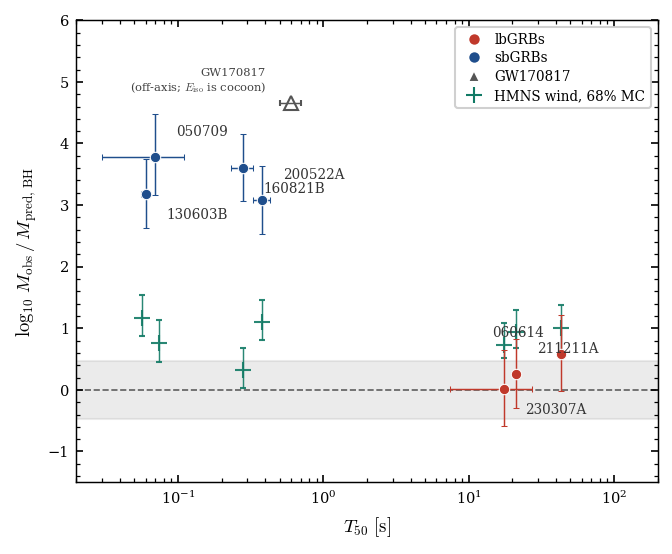


BH-engine null hypothesis test
------------------------------
  lbGRBs:  <log10 R> = +0.34  (N=3, +/- 0.45),  BH-null offset = +0.8 sigma,  log10 B10(HMNS/BH) = -3.3
  sbGRBs:  <log10 R> = +3.45  (N=4, +/- 0.35),  BH-null offset = +9.7 sigma,  log10 B10(HMNS/BH) = +24.3


In [8]:
from scipy import stats


def _mc_log_ratio(row, posteriors, n=10_000, seed=None):
    """Joint posterior on log10(M_obs / M_pred_BH) for one event."""
    rng = np.random.default_rng(seed)
    pred = predict_bh_mc(row, n=n, rng=rng)
    obs_pool = posteriors[row["name"]]["M_tot"]
    obs = rng.choice(obs_pool, size=n, replace=True)
    obs = np.clip(obs, 1e-8, None)
    pred = np.clip(pred, 1e-30, None)
    return np.log10(obs / pred)


def _hmns_log_ratio(row, posteriors, n=10_000, seed=None,
                    M_disk_range=HMNS_DISK_RANGE, wind_frac=WIND_FRAC):
    """log10(M_obs / M_HMNS) drawn from the joint posterior."""
    rng = np.random.default_rng(seed)
    obs_pool = posteriors[row["name"]]["M_tot"]
    obs = rng.choice(obs_pool, size=n, replace=True)
    md = rng.uniform(*M_disk_range, size=n)
    pred = wind_frac * md
    return np.log10(np.clip(obs, 1e-8, None) / np.clip(pred, 1e-8, None))


def wind_frac_apply(rng, n, M_disk_range=HMNS_DISK_RANGE, wind_frac=WIND_FRAC):
    return wind_frac * rng.uniform(*M_disk_range, size=n)


def bayes_factor_bh_vs_hmns(rows, posteriors, n=10_000, seed=42):
    """Gaussian-in-log-space Bayes factor B10 = P(D | HMNS) / P(D | BH).

    For each event we estimate the predictive distribution under each model
    from the MC draws (mean and std in log10 mass), then evaluate the
    Gaussian likelihood at the observed mean log mass and combine across
    events.  Returns log10 B10.
    """
    log10_B = 0.0
    rng_seq = np.random.SeedSequence(seed)
    for i, (_, row) in enumerate(rows.iterrows()):
        rng_bh   = np.random.default_rng(rng_seq.spawn(1)[0])
        rng_hmns = np.random.default_rng(rng_seq.spawn(1)[0])
        pred_bh   = np.log10(np.clip(predict_bh_mc(row, n=n, rng=rng_bh),
                                     1e-30, None))
        pred_hmns = np.log10(wind_frac_apply(rng_hmns, n))
        obs_log   = np.log10(np.clip(posteriors[row["name"]]["M_tot"],
                                     1e-8, None))
        obs_mean = np.mean(obs_log)
        obs_std  = np.std(obs_log) + 1e-3
        mu_bh,   sig_bh   = pred_bh.mean(),   pred_bh.std()
        mu_hmns, sig_hmns = pred_hmns.mean(), pred_hmns.std()
        sig_bh_eff   = np.sqrt(sig_bh**2   + obs_std**2)
        sig_hmns_eff = np.sqrt(sig_hmns**2 + obs_std**2)
        log_L_bh   = stats.norm.logpdf(obs_mean, mu_bh,   sig_bh_eff)
        log_L_hmns = stats.norm.logpdf(obs_mean, mu_hmns, sig_hmns_eff)
        log10_B += (log_L_hmns - log_L_bh) / np.log(10.0)
    return log10_B


def plot_fig2(df, posteriors, savepath_pdf, n=10_000, seed=20260417):
    """Residual plot M_obs / M_pred_BH with asymmetric MC error bars."""
    rng_seq = np.random.SeedSequence(seed)
    fig, ax = plt.subplots(figsize=(5.0, 4.0))

    ax.axhspan(np.log10(1.0 / 3.0), np.log10(3.0),
               color="0.7", alpha=0.25, label=r"factor 3 of $M_{\rm pred}$")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.6)

    rows_for_test = {"sb": [], "lb": [], "gw": []}

    # Per-event annotation offsets in (dx_pt, dy_pt, ha).  Default keeps the
    # legacy (8, -3, "left") for any unlisted event.  Entries below pull the
    # label off the dot so the marker is not painted through the text, and
    # left-shift 060614 so it clears the right axis.
    LABEL_OFFSETS_F2 = {
        "050709":  (10,  10, "left"),
        "130603B": (10, -12, "left"),
        "160821B": (10, -12, "left"),
        "200522A": (10,  10, "left"),
        "211211A": (10,  10, "left"),
        "230307A": (10, -12, "left"),
        "060614":  (-8,   8, "right"),
    }
    # Tiny multiplicative x-jitter applied only to the green HMNS cross so
    # that 050709 and 130603B (T50 ~ 0.07 vs 0.06 s) do not draw on top of
    # each other.  The colored data dot stays at the true T50.
    HMNS_CROSS_JITTER = {
        "050709":  1.05,
        "130603B": 0.95,
    }

    for i, (_, row) in enumerate(df.iterrows()):
        cls = row.grb_class
        style = CLASS_STYLE[cls]
        seed_i = rng_seq.spawn(1)[0]
        log_R_bh   = _mc_log_ratio(row, posteriors, n=n, seed=seed_i)
        log_R_hmns = _hmns_log_ratio(row, posteriors, n=n,
                                     seed=rng_seq.spawn(1)[0])
        med = np.median(log_R_bh)
        lo  = med - np.percentile(log_R_bh, 16)
        hi  = np.percentile(log_R_bh, 84) - med
        if cls == "gw":
            # GW170817's prompt E_iso is from off-axis cocoon emission, not a
            # prompt jet, so applying eq11 here is a model misapplication
            # rather than a measurement discrepancy.  Show it as an open
            # marker with no y-error bar, annotate the systematic, and skip
            # the HMNS comparison cross (a one-sided "consistent with HMNS"
            # claim against a missing BH bar would overreach).
            ax.errorbar(row.T50_s, med,
                        xerr=[[row.T50_err_s], [row.T50_err_s]],
                        yerr=None,
                        fmt=style["marker"], ms=7,
                        mfc="none", mec=style["color"],
                        ecolor=style["color"],
                        elinewidth=0.7, capsize=1.5, mew=1.0,
                        zorder=5)
            ax.annotate("GW170817\n(off-axis; $E_{\\rm iso}$ is cocoon)",
                        xy=(row.T50_s, med),
                        xytext=(-12, 6), textcoords="offset points",
                        ha="right",
                        fontsize=5.5, color="0.25", zorder=6)
        else:
            ax.errorbar(row.T50_s, med,
                        xerr=[[row.T50_err_s], [row.T50_err_s]],
                        yerr=[[lo], [hi]],
                        fmt=style["marker"], ms=5,
                        color=style["color"], ecolor=style["color"],
                        elinewidth=0.7, capsize=1.5, mec="white", mew=0.5,
                        zorder=5)
            # HMNS-wind comparison cross: now carries the same 16/84-pct MC
            # uncertainty as the BH dot, so the "ratio collapses to ~1 under
            # HMNS" claim is supported by visible posterior+model spread
            # rather than a bare median.
            med_h = np.median(log_R_hmns)
            lo_h  = med_h - np.percentile(log_R_hmns, 16)
            hi_h  = np.percentile(log_R_hmns, 84) - med_h
            x_h = row.T50_s * HMNS_CROSS_JITTER.get(row["name"], 1.0)
            ax.errorbar(x_h, med_h,
                        yerr=[[lo_h], [hi_h]],
                        fmt="+", ms=8, mew=1.0,
                        color="#117a65", ecolor="#117a65",
                        elinewidth=0.7, capsize=1.5, alpha=0.9,
                        zorder=4)
            dx, dy, ha = LABEL_OFFSETS_F2.get(row["name"], (8, -3, "left"))
            ax.annotate(row["name"], xy=(row.T50_s, med),
                        xytext=(dx, dy), textcoords="offset points",
                        ha=ha,
                        fontsize=6.5, color="0.2", zorder=6)
        rows_for_test[cls].append((row, log_R_bh, log_R_hmns))

    ax.set_xscale("log")
    ax.set_xlim(0.02, 200)
    ax.set_ylim(-1.5, 6.0)
    ax.set_xlabel(r"$T_{50}\ [{\rm s}]$")
    ax.set_ylabel(r"$\log_{10}\,M_{\rm obs}\,/\,M_{\rm pred,\,BH}$")

    handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=6,
                   label="lbGRBs"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=6,
                   label="sbGRBs"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=6,
                   label="GW170817"),
        plt.Line2D([0], [0], marker="+", color="#117a65", lw=0,
                   markersize=8, mew=1.0, label="HMNS wind, 68% MC"),
    ]
    ax.legend(handles=handles, loc="upper right",
              fontsize=6.5, borderpad=0.4, handletextpad=0.5,
              labelspacing=0.35)

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig, rows_for_test


fig2, perclass = plot_fig2(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig2.pdf"),
)
plt.show()


# ---------------------------------------------------------------------------
# Quantitative test of the BH-engine null per subclass.
# ---------------------------------------------------------------------------
print("\nBH-engine null hypothesis test")
print("------------------------------")
for cls in ("lb", "sb"):
    rows = df[df.grb_class == cls]
    log_ratios = []
    rng_seq = np.random.SeedSequence(424242 + ord(cls[0]))
    for _, row in rows.iterrows():
        log_ratios.append(_mc_log_ratio(row, posteriors, n=10_000,
                                        seed=rng_seq.spawn(1)[0]))
    stacked = np.stack(log_ratios, axis=0)
    per_event_mean = stacked.mean(axis=1)
    per_event_std  = stacked.std(axis=1)
    sample_mean = per_event_mean.mean()
    sample_se   = np.sqrt(np.sum(per_event_std**2)) / len(per_event_mean)
    sigma = sample_mean / sample_se if sample_se > 0 else np.inf
    log10_B = bayes_factor_bh_vs_hmns(rows, posteriors, n=10_000,
                                      seed=11000 + ord(cls[0]))
    label = "lbGRBs" if cls == "lb" else "sbGRBs"
    print(f"  {label}:  <log10 R> = {sample_mean:+.2f}  "
          f"(N={len(rows)}, +/- {sample_se:.2f}),  "
          f"BH-null offset = {sigma:+.1f} sigma,  "
          f"log10 B10(HMNS/BH) = {log10_B:+.1f}")
